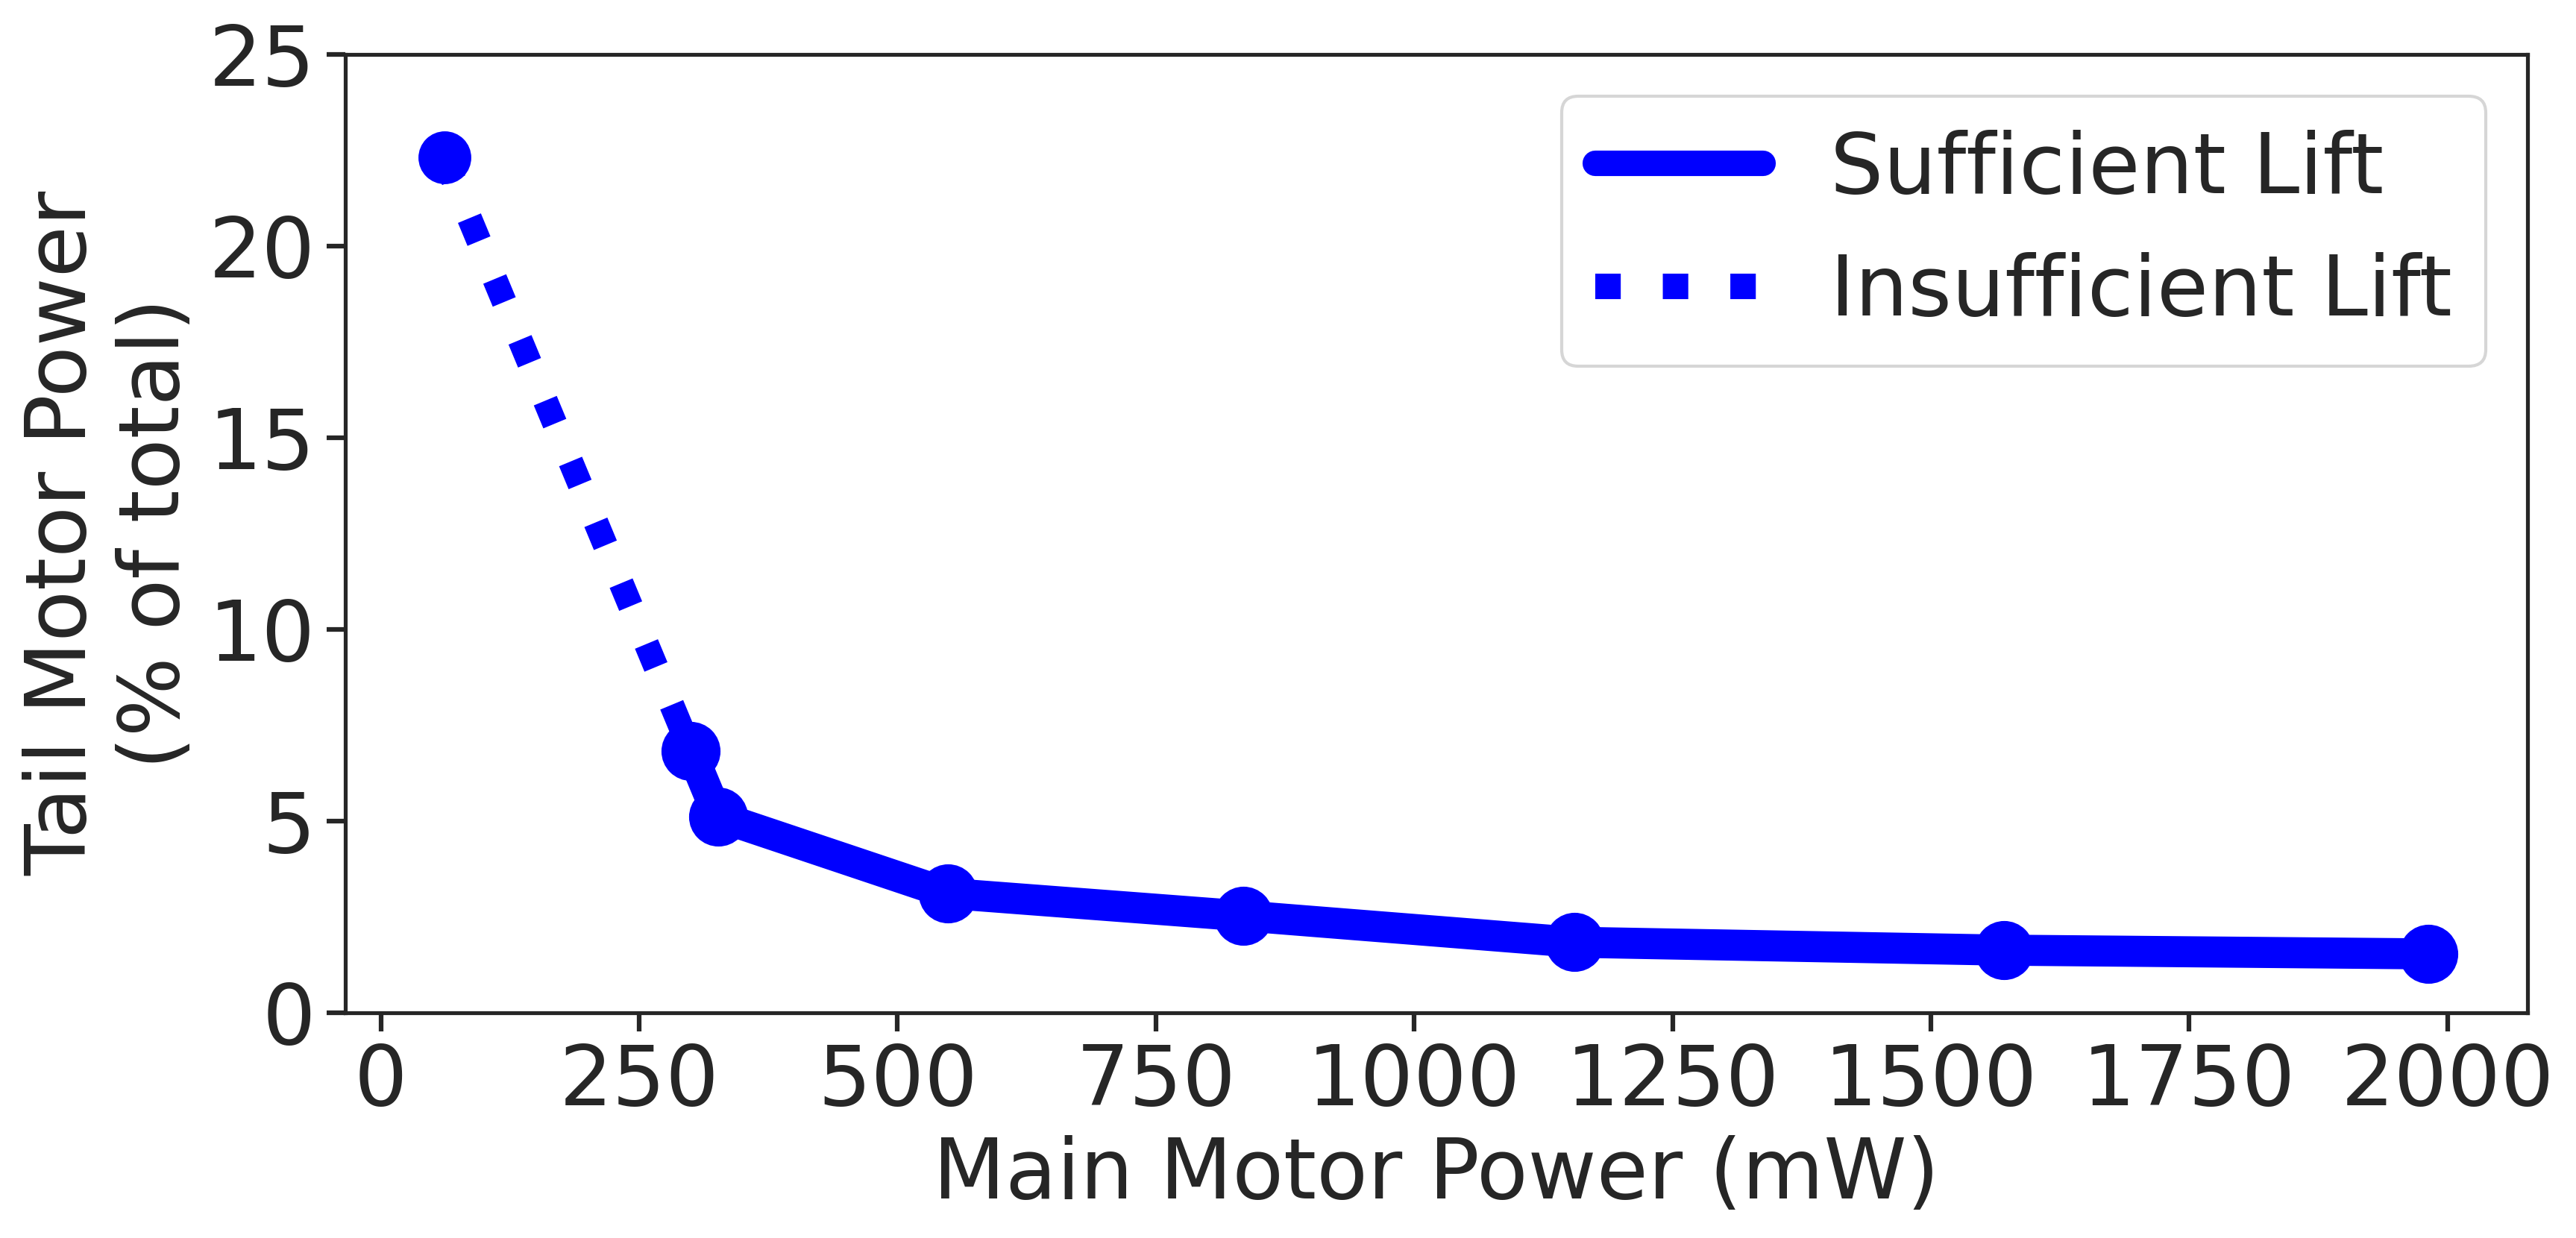

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

# === Load Dataset ===
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSnrBfgvPmr8fwEJ7atZ1SiwbERd7q6J6bwe7W7hOgcof2wazMdo6WG0FCxhB8_z7omYWcmCT99cNbC/pub?output=csv"
df = pd.read_csv(url)

# === Drop Rows at Index 0 and 2 ===
df = df.drop(index=[0, 2]).reset_index(drop=True)

# === Smooth the data using a rolling average ===
df["Main Smooth"] = df["Main Motor Power (mW)"].rolling(window=1, min_periods=1).mean()
df["Tail Smooth"] = df["Tail Motor Power (mW)"].rolling(window=1, min_periods=1).mean()

# === Set Plot Style ===
sns.set_theme(style="white")
#sns.set_theme(style="whitegrid")

# === Threshold and Interpolation ===
threshold = 300 # 466 mW for sufficient lift

transition_idx = df["Main Smooth"].ge(threshold).idxmax()

# === Compute Tail Power Percentage ===
df["Total Power"] = df["Main Smooth"] + df["Tail Smooth"]
df["Tail %"] = (df["Tail Smooth"] / df["Total Power"]) * 100

# Update interpolation logic so it calculates Tail % instead of Tail Smooth
if transition_idx > 0 and df["Main Smooth"].iloc[transition_idx - 1] < threshold:
    x0, x1 = df["Main Smooth"].iloc[transition_idx - 1], df["Main Smooth"].iloc[transition_idx]
    y0, y1 = df["Tail %"].iloc[transition_idx - 1], df["Tail %"].iloc[transition_idx]

    slope = (y1 - y0) / (x1 - x0)
    tail_at_threshold = y0 + slope * (threshold - x0)

    interpolated_point = pd.DataFrame({
        "Main Smooth": [threshold],
        "Tail %": [tail_at_threshold]
    })

    below_threshold = pd.concat([
        df[df["Main Smooth"] < threshold][["Main Smooth", "Tail %"]],
        interpolated_point
    ])
    above_threshold = pd.concat([
        interpolated_point,
        df[df["Main Smooth"] >= threshold][["Main Smooth", "Tail %"]]
    ])
else:
    below_threshold = df[df["Main Smooth"] < threshold][["Main Smooth", "Tail %"]]
    above_threshold = df[df["Main Smooth"] >= threshold][["Main Smooth", "Tail %"]]

# === Plot ===
plt.figure(figsize=(12, 6), dpi=300)

line1, = plt.plot(
    below_threshold["Main Smooth"],
    below_threshold["Tail %"],
    linestyle=":",
    color="blue",
    linewidth=8,
    marker="o",
    markersize=16,
    markerfacecolor="blue",
)

line2, = plt.plot(
    above_threshold["Main Smooth"],
    above_threshold["Tail %"],
    linestyle="-",
    color="blue",
    linewidth=10,
    marker="o",
    markersize=18,
    markerfacecolor="blue"
)

# === Customize Plot ===
plt.xlabel("Main Motor Power (mW)", fontsize=27)
plt.ylabel("Tail Motor Power\n(% of total)", fontsize=27)
# === Hide grid ===
ax = plt.gca()
ax.grid(False)
# === Small outward ticks ===
ax.tick_params(axis='both', which='both',
               direction='out', length=6, width=1.5,
               bottom=True, top=False, left=True, right=False)
# plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.xticks(fontsize=27)
plt.yticks(np.arange(0, 26, 5), fontsize=27)
# plt.grid(False)
plt.tight_layout(pad=2.0)

# === Legend 2: Feasibility ===
feasible_patch = Line2D([0], [0], color="blue", linewidth=8.2, linestyle="-", label="Sufficient Lift")
infeasible_patch = Line2D([0], [0], color="blue", linewidth=8.2, linestyle=":", label="Insufficient Lift")

plt.legend(handles=[feasible_patch, infeasible_patch], loc="upper right", fontsize=27) # bbox_to_anchor=(0.01, 0.83)

plt.show()